In [3]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt

In [4]:
G = 1 # unidades canonicas

m1 = 1
m2 = 1
r1_vec_0 = np.array([0, 0, 0])
v1_vec_0 = np.array([0, 0, 0])

r2_vec_0 = np.array([1, 0, 0])
v2_vec_0 = np.array([0, 1, 0])

La pregunta que se hace la persona es ¿Cual es la trayectoria que siguen esas dos particulas con esas condiciones iniciales?

In [8]:
#La pregunta que se hace la persona es: 
# ¿Cual es la trayectoria que siguen esas dos particulas con esas condiciones iniciales?
mu = G * (m1 + m2)

r_vec_0 = r1_vec_0 - r2_vec_0
r_vec_0_norm = np.linalg.norm(r_vec_0)
v_vec_0 = v1_vec_0 - v2_vec_0
v_vec_0_norm = np.linalg.norm(v_vec_0)


ctrl + shift +7

In [7]:
# calcularemos las cuadraturas de los dos cuerpos

h_vec = np.cross(r_vec_0, v_vec_0)
#h = np.linalg.norm(h_vec)
h = np.sqrt(h_vec[0]**2 + h_vec[1]**2 + h_vec[2]**2)

h_vec, h

(array([0, 0, 1]), np.float64(1.0))

In [ ]:
e_vec = (np.cross(v_vec_0, h_vec) / mu) - (r_vec_0 / r_vec_0_norm)# apunta hacia el periaxis 
e = np.linalg.norm(e_vec) # es la excentricidad de la orbita
e_vec, e 


(array([0.5, 0. , 0. ]), np.float64(0.5))

In [ ]:
epsilon = (v_vec_0_norm**2 / 2) - (mu / r_vec_0_norm) # es la energia especifica de la orbita

epsilon 

np.float64(-1.5)

In [ ]:
# verifiquemos la formula e = sqrt(1 + (2 * epsilon * h**2) / mu**2)
e = np.sqrt(1 + (2 * epsilon * h**2) / mu**2)
e # es la excentricidad de la orbita me dice que la orbita es una elipse, porque e < 1

np.float64(0.5)

In [ ]:
p = h**2 / mu # es el parametro de la orbita
q = p / (1 + e) # es el periapsis de la orbita
Q = p / (1 - e) # es el apoapsis de la orbita
p, q, Q

(np.float64(0.5), np.float64(0.3333333333333333), np.float64(1.0))

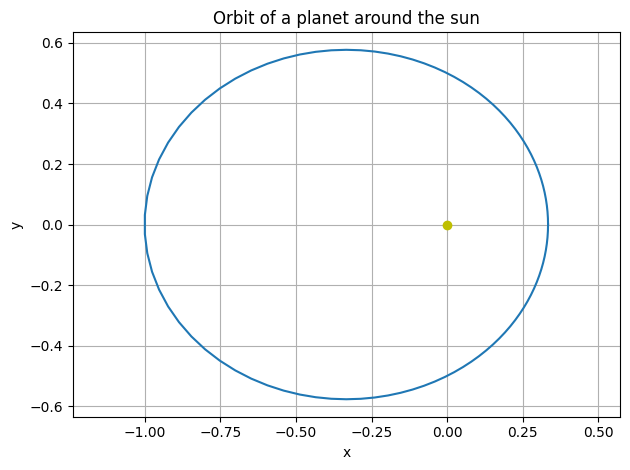

In [14]:
#grafiquemos la orbita

theta = np.linspace(0, 2*np.pi, 100)
rs= p / (1 + e* np.cos(theta))

xfs = rs * np.cos(theta)
yfs = rs * np.sin(theta)
# pondremos el origen en el foco

plt.plot(xfs, yfs)
plt.plot(0, 0, 'yo', label='Sun')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Orbit of a planet around the sun')
plt.grid()
plt.axis('equal')
plt.tight_layout()
plt.show()

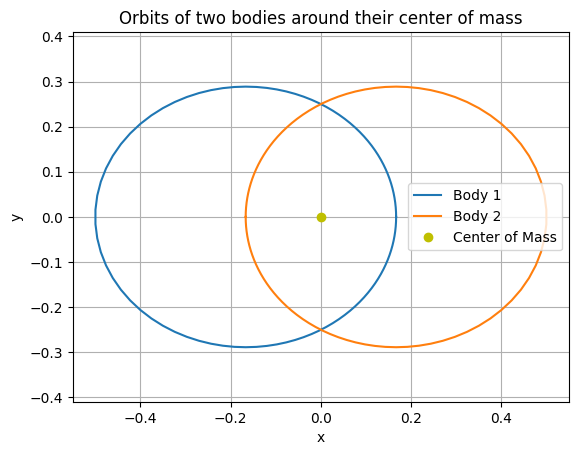

In [17]:
M = m1 + m2

rsvec = np.array([xfs, yfs]).T

r1svec = m2 / M * rsvec
r2svec =- m1 / M * rsvec 

plt.plot(r1svec[:, 0], r1svec[:, 1], label='Body 1')
plt.plot(r2svec[:, 0], r2svec[:, 1], label='Body 2')
plt.plot(0, 0, 'yo', label='Center of Mass')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Orbits of two bodies around their center of mass')
plt.grid()  
plt.axis('equal')
plt.legend()
plt.show()

In [18]:
sistema = [
    dict(r = r1_vec_0, v = v1_vec_0, m = m1),
    dict(r = r2_vec_0, v = v2_vec_0, m = m2)
]
ts = np.linspace(0, 10, 100)
rs, vs, rps, vps, constantes = pc.ncuerpos_solucion(sistema, ts,)

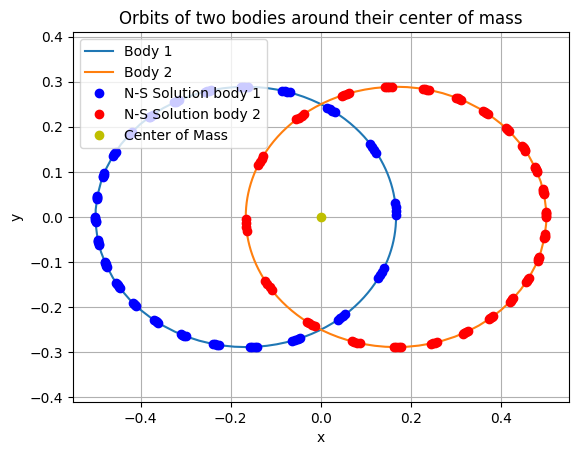

In [20]:
M = m1 + m2

rsvec = np.array([xfs, yfs]).T

r1svec = m2 / M * rsvec
r2svec =- m1 / M * rsvec 

plt.plot(r1svec[:, 0], r1svec[:, 1], label='Body 1')
plt.plot(r2svec[:, 0], r2svec[:, 1], label='Body 2')

plt.plot(rps[0,:, 0], rps[0,:, 1], 'bo', label='N-S Solution body 1')
plt.plot(rps[1,:, 0], rps[1,:, 1], 'ro', label='N-S Solution body 2')

plt.plot(0, 0, 'yo', label='Center of Mass')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Orbits of two bodies around their center of mass')
plt.grid()  
plt.axis('equal')
plt.legend()
plt.show()

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Posiciones en 2D (x, y) de cada cuerpo
r1 = rps[0, :, :2]
r2 = rps[1, :, :2]

# Centro de masa (opcional, para visualizarlo)
M = m1 + m2
com = (m1 * r1 + m2 * r2) / M

# Limites del grafico
all_xy = np.vstack([r1, r2])
xmin, ymin = all_xy.min(axis=0)
xmax, ymax = all_xy.max(axis=0)
dx, dy = xmax - xmin, ymax - ymin
pad = 0.15 * max(dx, dy, 1e-6)

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(xmin - pad, xmax + pad)
ax.set_ylim(ymin - pad, ymax + pad)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Animacion del sistema de 2 cuerpos")

# Trayectorias y puntos
tr1, = ax.plot([], [], "b-", lw=1.5, alpha=0.5)
tr2, = ax.plot([], [], "r-", lw=1.5, alpha=0.5)
p1,  = ax.plot([], [], "bo", ms=8, label="Cuerpo 1")
p2,  = ax.plot([], [], "ro", ms=8, label="Cuerpo 2")
pcm, = ax.plot([], [], "ko", ms=5, label="Centro de masa")
ttxt = ax.text(0.02, 0.95, "", transform=ax.transAxes)

ax.legend(loc="upper right")

def init():
    tr1.set_data([], [])
    tr2.set_data([], [])
    p1.set_data([], [])
    p2.set_data([], [])
    pcm.set_data([], [])
    ttxt.set_text("")
    return tr1, tr2, p1, p2, pcm, ttxt

def update(i):
    tr1.set_data(r1[:i+1, 0], r1[:i+1, 1])
    tr2.set_data(r2[:i+1, 0], r2[:i+1, 1])

    p1.set_data([r1[i, 0]], [r1[i, 1]])
    p2.set_data([r2[i, 0]], [r2[i, 1]])
    pcm.set_data([com[i, 0]], [com[i, 1]])

    ttxt.set_text(f"t = {ts[i]:.2f}")
    return tr1, tr2, p1, p2, pcm, ttxt

ani = FuncAnimation(
    fig, update, frames=len(ts), init_func=init,
    interval=40, blit=True
)

plt.close(fig)
HTML(ani.to_jshtml())